In [2]:
import pandas as pd

In [3]:
import os
def get_data_files_path (path, type):
    return [ path + f for f in os.listdir(path) if f.endswith(type)]

In [4]:
files_path = 'Sales/'
list_of_file = []

list_of_file.extend(get_data_files_path(files_path, 'csv'))
print(list_of_file)

['Sales/Sales_April_2019.csv', 'Sales/Sales_August_2019.csv', 'Sales/Sales_December_2019.csv', 'Sales/Sales_February_2019.csv', 'Sales/Sales_January_2019.csv', 'Sales/Sales_July_2019.csv', 'Sales/Sales_June_2019.csv', 'Sales/Sales_March_2019.csv', 'Sales/Sales_May_2019.csv', 'Sales/Sales_November_2019.csv', 'Sales/Sales_October_2019.csv', 'Sales/Sales_September_2019.csv']


In [5]:
for file in  list_of_file :
    _ = pd.read_csv(file)
    print(f"information about file {file}")
    print(_.info())

information about file Sales/Sales_April_2019.csv
<class 'pandas.DataFrame'>
RangeIndex: 18383 entries, 0 to 18382
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Order ID          18324 non-null  str  
 1   Product           18324 non-null  str  
 2   Quantity Ordered  18324 non-null  str  
 3   Price Each        18324 non-null  str  
 4   Order Date        18324 non-null  str  
 5   Purchase Address  18324 non-null  str  
dtypes: str(6)
memory usage: 861.8 KB
None
information about file Sales/Sales_August_2019.csv
<class 'pandas.DataFrame'>
RangeIndex: 12011 entries, 0 to 12010
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Order ID          11983 non-null  str  
 1   Product           11983 non-null  str  
 2   Quantity Ordered  11983 non-null  str  
 3   Price Each        11983 non-null  str  
 4   Order Date        11983 non

In [6]:
df_list = [pd.read_csv(f) for f in list_of_file]
df = pd.concat(df_list, ignore_index=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Order ID          186305 non-null  str  
 1   Product           186305 non-null  str  
 2   Quantity Ordered  186305 non-null  str  
 3   Price Each        186305 non-null  str  
 4   Order Date        186305 non-null  str  
 5   Purchase Address  186305 non-null  str  
dtypes: str(6)
memory usage: 8.6 MB


In [7]:
df.nunique()
print(df.head()) 

  Order ID                     Product Quantity Ordered Price Each  \
0   176558        USB-C Charging Cable                2      11.95   
1      NaN                         NaN              NaN        NaN   
2   176559  Bose SoundSport Headphones                1      99.99   
3   176560                Google Phone                1        600   
4   176560            Wired Headphones                1      11.99   

       Order Date                      Purchase Address  
0  04/19/19 08:46          917 1st St, Dallas, TX 75001  
1             NaN                                   NaN  
2  04/07/19 22:30     682 Chestnut St, Boston, MA 02215  
3  04/12/19 14:38  669 Spruce St, Los Angeles, CA 90001  
4  04/12/19 14:38  669 Spruce St, Los Angeles, CA 90001  


In [8]:
df.rename(columns={
    "Order ID":"order_id",
    "Product":"product",
    "Quantity Ordered":"quantity_ordered",
    "Price Each":"price_each",
    "Order Date":"order_date",
    "Purchase Address":"purchase_address",
},inplace=True)

In [9]:
print(df.isnull().sum())
# Rows where ALL values are null
print(len(df[df.isnull().all(axis=1)]))
# Rows with at least one null value
print(len(df[df.isnull().any(axis=1)]))

order_id            545
product             545
quantity_ordered    545
price_each          545
order_date          545
purchase_address    545
dtype: int64
545
545


In [10]:
df.dropna(inplace=True)
df

,order_id,product,quantity_ordered,price_each,order_date,purchase_address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


In [11]:
df = df[df['quantity_ordered'] != 'Quantity Ordered']
df = df[df['price_each'] != 'Price Each']
df = df[df['order_id'] != 'Order ID']
df = df[df['order_date'] != 'Order Date']
df = df[df['purchase_address'] != 'Purchase Address']
df = df[df['product'] != 'Product']
df = df.astype({"quantity_ordered": "int64", "price_each": "float64"})



In [12]:
df['quantity_ordered'].unique()

df.info()

<class 'pandas.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          185950 non-null  str    
 1   product           185950 non-null  str    
 2   quantity_ordered  185950 non-null  int64  
 3   price_each        185950 non-null  float64
 4   order_date        185950 non-null  str    
 5   purchase_address  185950 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.9 MB


In [13]:
def get_mounth(mounth):
    match mounth:
        case 1: return "january"
        case 2: return "february" 
        case 3: return "march"
        case 4: return "april"
        case 5: return "may"
        case 6: return "june"
        case 7: return "july"
        case 8: return "august"
        case 9: return "september"
        case 10: return "october"
        case 11: return "november"
        case 12: return "december"

        case _: return "january"
df["mounth"]=[get_mounth(int(date.split('/')[0])) for date in df['order_date']]


In [14]:
df.dropna(inplace=True)
df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,mounth
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",april
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",april
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",april
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",april
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",april


In [15]:
df['sales'] = df['quantity_ordered'] * df['price_each']
df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,mounth,sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",april,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",april,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",april,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",april,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",april,11.99


In [16]:
mouth_sales = df.groupby('mounth')['sales'].agg(sales_sum = 'sum').sort_values('sales_sum', ascending=False).reset_index()
mouth_sales

,mounth,sales_sum
0,december,4613443.34
1,october,3736726.88
2,april,3390670.24
3,november,3199603.20
4,may,3152606.75
5,march,2807100.38
6,july,2647775.76
7,june,2577802.26
8,august,2244467.88
9,february,2202022.42


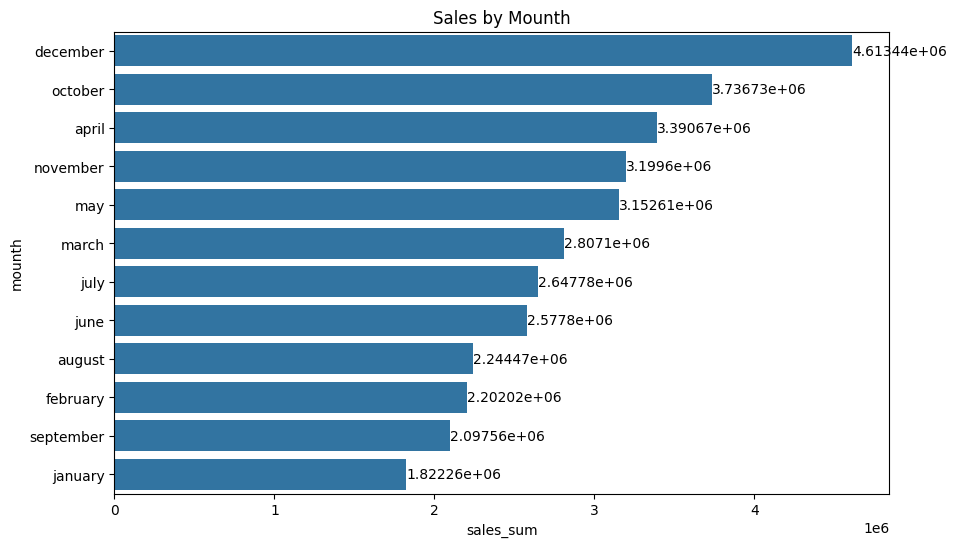

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(x='sales_sum', y='mounth', data=mouth_sales)
plt.title('Sales by Mounth')
ax.bar_label(ax.containers[0])
plt.show()

In [18]:
df['city'] = df['purchase_address'].str.split(',').str[1]
city_sales = df.groupby('city')['sales'].agg(sales_sum = 'sum').sort_values('sales_sum', ascending=False).reset_index()
city_sales

,city,sales_sum
0,San Francisco,8262203.91
1,Los Angeles,5452570.80
2,New York City,4664317.43
3,Boston,3661642.01
4,Atlanta,2795498.58
5,Dallas,2767975.40
6,Seattle,2747755.48
7,Portland,2320490.61
8,Austin,1819581.75


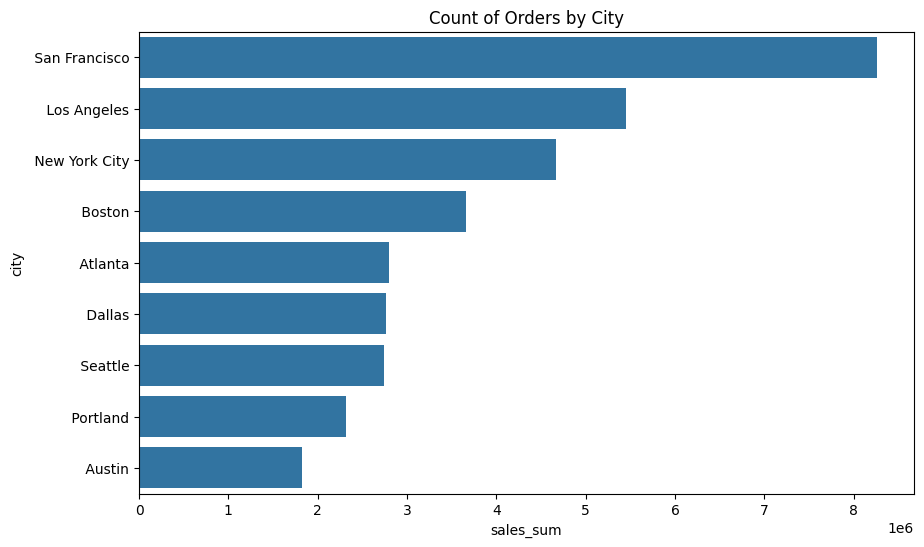

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='sales_sum', y='city', data=city_sales)
plt.title('Count of Orders by City')
plt.show()

In [22]:
df.nunique()

order_id            178437
product                 19
quantity_ordered         9
price_each              17
order_date          142395
purchase_address    140787
mounth                  12
sales                   54
city                     9
dtype: int64

In [ ]:
product_sales_with_quantity = df.groupby('product')['quantity_ordered'].agg(quantity_ordered= 'sum').sort_values("quantity_ordered", ascending=False).reset_index()
product_sales_with_quantity

,product,quantity_ordered
0,AAA Batteries (4-pack),31017
1,AA Batteries (4-pack),27635
2,USB-C Charging Cable,23975
3,Lightning Charging Cable,23217
4,Wired Headphones,20557
5,Apple Airpods Headphones,15661
6,Bose SoundSport Headphones,13457
7,27in FHD Monitor,7550
8,iPhone,6849
9,27in 4K Gaming Monitor,6244


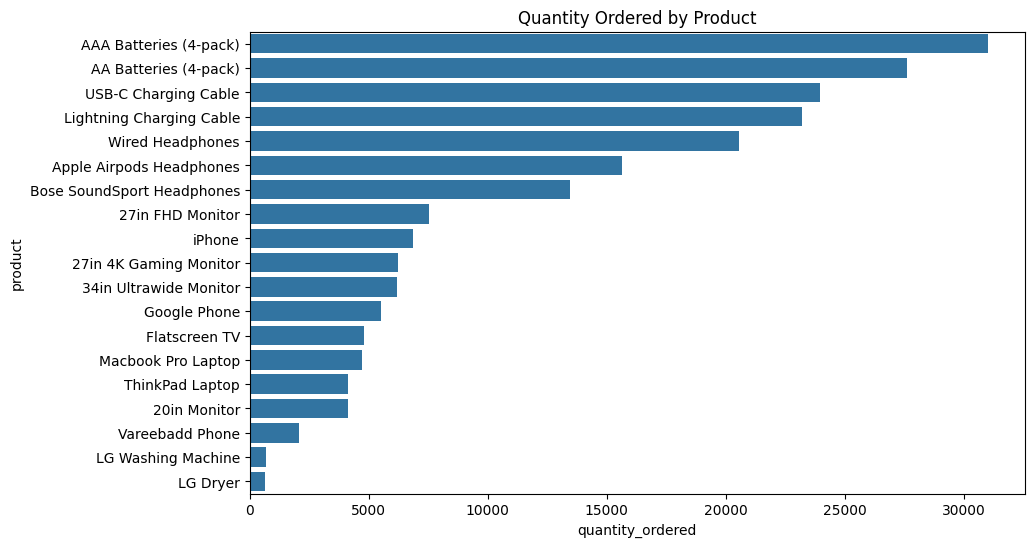

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='quantity_ordered', y='product', data=product_sales_with_quantity)
plt.title('Quantity Ordered by Product')
plt.show()

In [27]:
product_sales_price = df.groupby('product')['sales'].agg(product_sales= 'sum').sort_values("product_sales", ascending=False).reset_index()
product_sales_price

,product,product_sales
0,Macbook Pro Laptop,8037600.00
1,iPhone,4794300.00
2,ThinkPad Laptop,4129958.70
3,Google Phone,3319200.00
4,27in 4K Gaming Monitor,2435097.56
5,34in Ultrawide Monitor,2355558.01
6,Apple Airpods Headphones,2349150.00
7,Flatscreen TV,1445700.00
8,Bose SoundSport Headphones,1345565.43
9,27in FHD Monitor,1132424.50


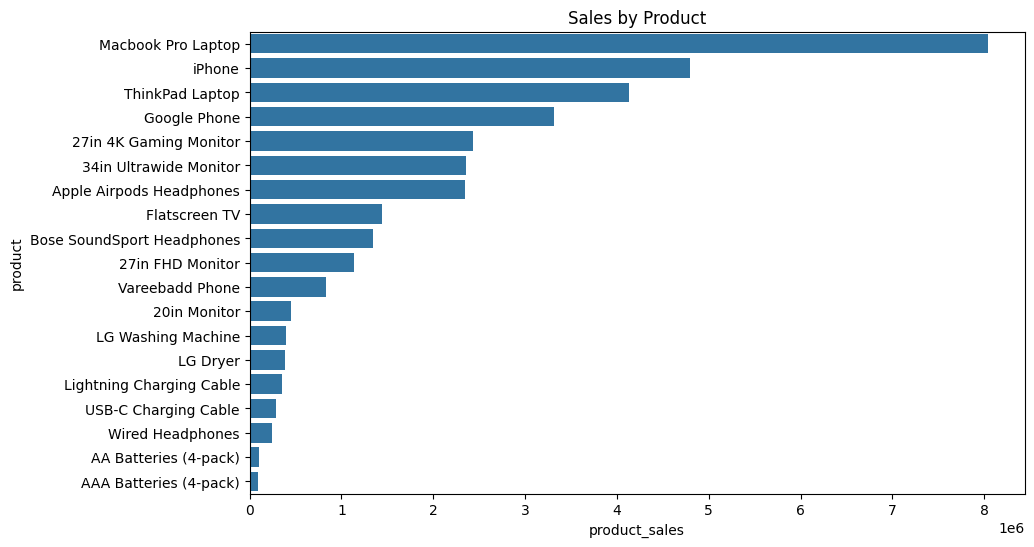

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='product_sales', y='product', data=product_sales_price)
plt.title('Sales by Product')
plt.show()

In [29]:
def get_time(date):
    return date.split(" ")[1]

df["time"] = df["order_date"].apply(get_time)
df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,mounth,sales,city,time
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",april,23.90,Dallas,08:46
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",april,99.99,Boston,22:30
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",april,600.00,Los Angeles,14:38
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",april,11.99,Los Angeles,14:38
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",april,11.99,Los Angeles,09:27


In [32]:
sales_by_hour = df.groupby('time')['sales'].agg(sales='sum').sort_values('sales', ascending=False).reset_index()
sales_by_hour

,time,sales
0,19:01,54503.14
1,12:21,54181.96
2,19:16,54156.39
3,20:13,53149.51
4,19:20,52903.41
...,...,...
1435,02:50,381.99
1436,03:57,317.63
1437,04:05,277.72
1438,03:59,177.29


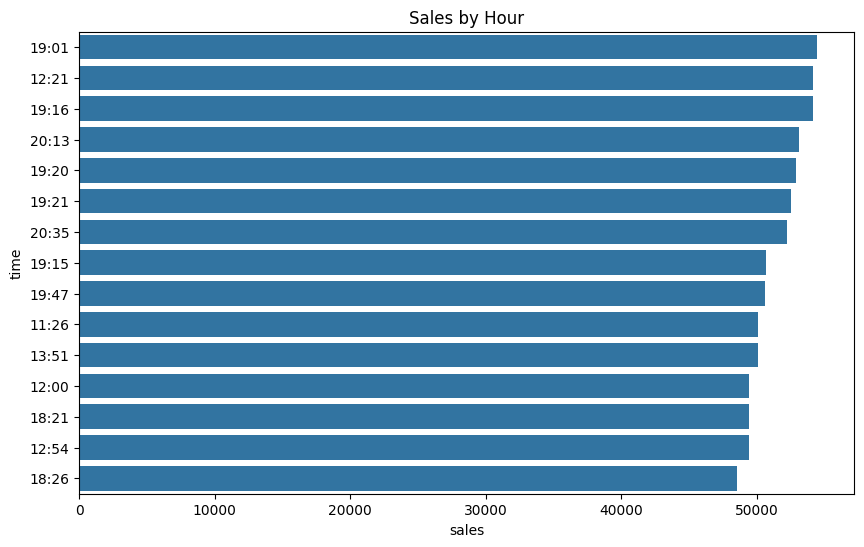

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='sales', y='time', data=sales_by_hour[:15])
plt.title('Sales by Hour')
plt.show()